In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Configuración de estilo para gráficos
sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = (12, 10)

# Ruta al archivo compilado (Ajusta el nombre si decidiste otro código al final)
FILE_PATH = '../data/processed/04_compiled/dataset_compiled_SDH1.csv'


In [2]:
# Leemos el dataset compilado
df = pd.read_csv(FILE_PATH)

# Convertimos Timestamps a índice datetime
df['Timestamps'] = pd.to_datetime(df['Timestamps'])
df = df.set_index('Timestamps').sort_index()

# Inspección rápida
print(f"Rango temporal: {df.index.min().date()} a {df.index.max().date()}")
print(f"Total de días: {len(df)}")
df.head()

Rango temporal: 2024-05-21 a 2026-01-15
Total de días: 605


,TEROS12_48cm_water-content_m3/m3,TEROS12_48cm_soil-temperature_degreeC,TEROS12_48cm_saturation-extract-ec_mS/cm,TEROS12_30cm_water-content_m3/m3,TEROS12_30cm_soil-temperature_degreeC,TEROS12_30cm_saturation-extract-ec_mS/cm,TEROS12_15cm_water-content_m3/m3,TEROS12_15cm_soil-temperature_degreeC,TEROS12_15cm_saturation-extract-ec_mS/cm,TEROS21_35cm_matric-potential_kPa,...,s2_B12,s2_ndvi,s2_ndwi,s2_mndwi,s2_ndmi,s2_ndmi2,s2_srt,s2_brightness,s2_greenness,s2_wetness
Timestamps,,,,,,,,,,,,,,,,,,,,,
2024-05-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-22,0.425,6.554,0.465,0.235,5.494,0.073,0.216,4.134,0.163,-0.162,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-23,0.416,6.629,0.908,0.238,5.712,0.084,0.213,3.804,0.164,-0.100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-24,0.422,6.576,0.919,0.237,5.643,0.078,0.212,3.605,0.163,-0.100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-25,0.428,6.480,0.660,0.236,5.507,0.073,0.211,3.410,0.163,-0.100,...,0.3139,0.04003,-0.080106,0.05144,0.131006,0.273968,0.393074,1.060766,-0.279018,-0.167837


In [3]:
# 1. Identificar columnas por fuente
cols_l89 = [c for c in df.columns if c.startswith('l89_')]
cols_s1  = [c for c in df.columns if c.startswith('s1_')]
cols_s2  = [c for c in df.columns if c.startswith('s2_')]

# 2. Las columnas in-situ son las que NO empiezan con esos prefijos
cols_insitu = [c for c in df.columns if c not in cols_l89 + cols_s1 + cols_s2]

print(f"Variables In-Situ: {len(cols_insitu)}")
print(f"Variables Landsat: {len(cols_l89)}")
print(f"Variables Sentinel-1: {len(cols_s1)}")
print(f"Variables Sentinel-2: {len(cols_s2)}")

Variables In-Situ: 16
Variables Landsat: 16
Variables Sentinel-1: 4
Variables Sentinel-2: 15


In [4]:
def create_subset(df_main, satellite_cols, insitu_cols):
    """
    Crea un subset con datos in-situ + un satélite específico,
    eliminando las filas donde no hay datos satelitales.
    """
    # Seleccionamos solo las columnas de interés
    cols_to_keep = insitu_cols + satellite_cols
    subset = df_main[cols_to_keep].copy()
    
    # Eliminamos filas donde TODAS las columnas del satélite sean NaN
    # (Basta con que falte una para que dropna actúe, pero 'how=all' en el subset es más seguro)
    subset = subset.dropna(subset=satellite_cols, how='any')
    
    return subset

# Generamos los 3 dataframes
df_landsat = create_subset(df, cols_l89, cols_insitu)
df_sentinel1 = create_subset(df, cols_s1, cols_insitu)
df_sentinel2 = create_subset(df, cols_s2, cols_insitu)

print(f"Días con datos Landsat coincidentes: {len(df_landsat)}")
print(f"Días con datos Sentinel-1 coincidentes: {len(df_sentinel1)}")
print(f"Días con datos Sentinel-2 coincidentes: {len(df_sentinel2)}")

Días con datos Landsat coincidentes: 60
Días con datos Sentinel-1 coincidentes: 166
Días con datos Sentinel-2 coincidentes: 169


In [5]:
def plot_correlation_matrix(df_subset, title, method='pearson'):
    """
    Grafica la matriz de correlación resaltando valores mayores a |0.5|.
    """
    # 1. Calcular correlación
    corr = df_subset.corr(method=method)

    # 2. Crear una matriz de anotaciones: 
    # Solo mostramos el valor si es >= 0.5 o <= -0.5
    annot_mask = corr.applymap(lambda x: f'{x:.2f}' if abs(x) >= 0.5 else "")

    # 3. Máscara para el triángulo superior
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # 4. Configuración del gráfico
    plt.figure(figsize=(14, 12))
    
    sns.heatmap(
        corr, 
        mask=mask, 
        cmap='vlag', 
        center=0, 
        square=True, 
        linewidths=.5, 
        annot=annot_mask.values, # Usamos nuestra máscara de texto
        fmt="",                   # Necesario para que acepte los strings de annot_mask
        cbar_kws={"shrink": .5},
        annot_kws={"size": 10, "weight": "bold"} # Resalta el texto
    )
    
    plt.title(f'Matriz de Correlación: {title}\n(Valores resaltados con |r| >= 0.5)', fontsize=16)
    plt.show()

/var/folders/jv/vkj2kxvs7vs4lb9_8bnqgr2h0000gn/T/ipykernel_1852/2305290274.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_mask = corr.applymap(lambda x: f'{x:.2f}' if abs(x) >= 0.5 else "")


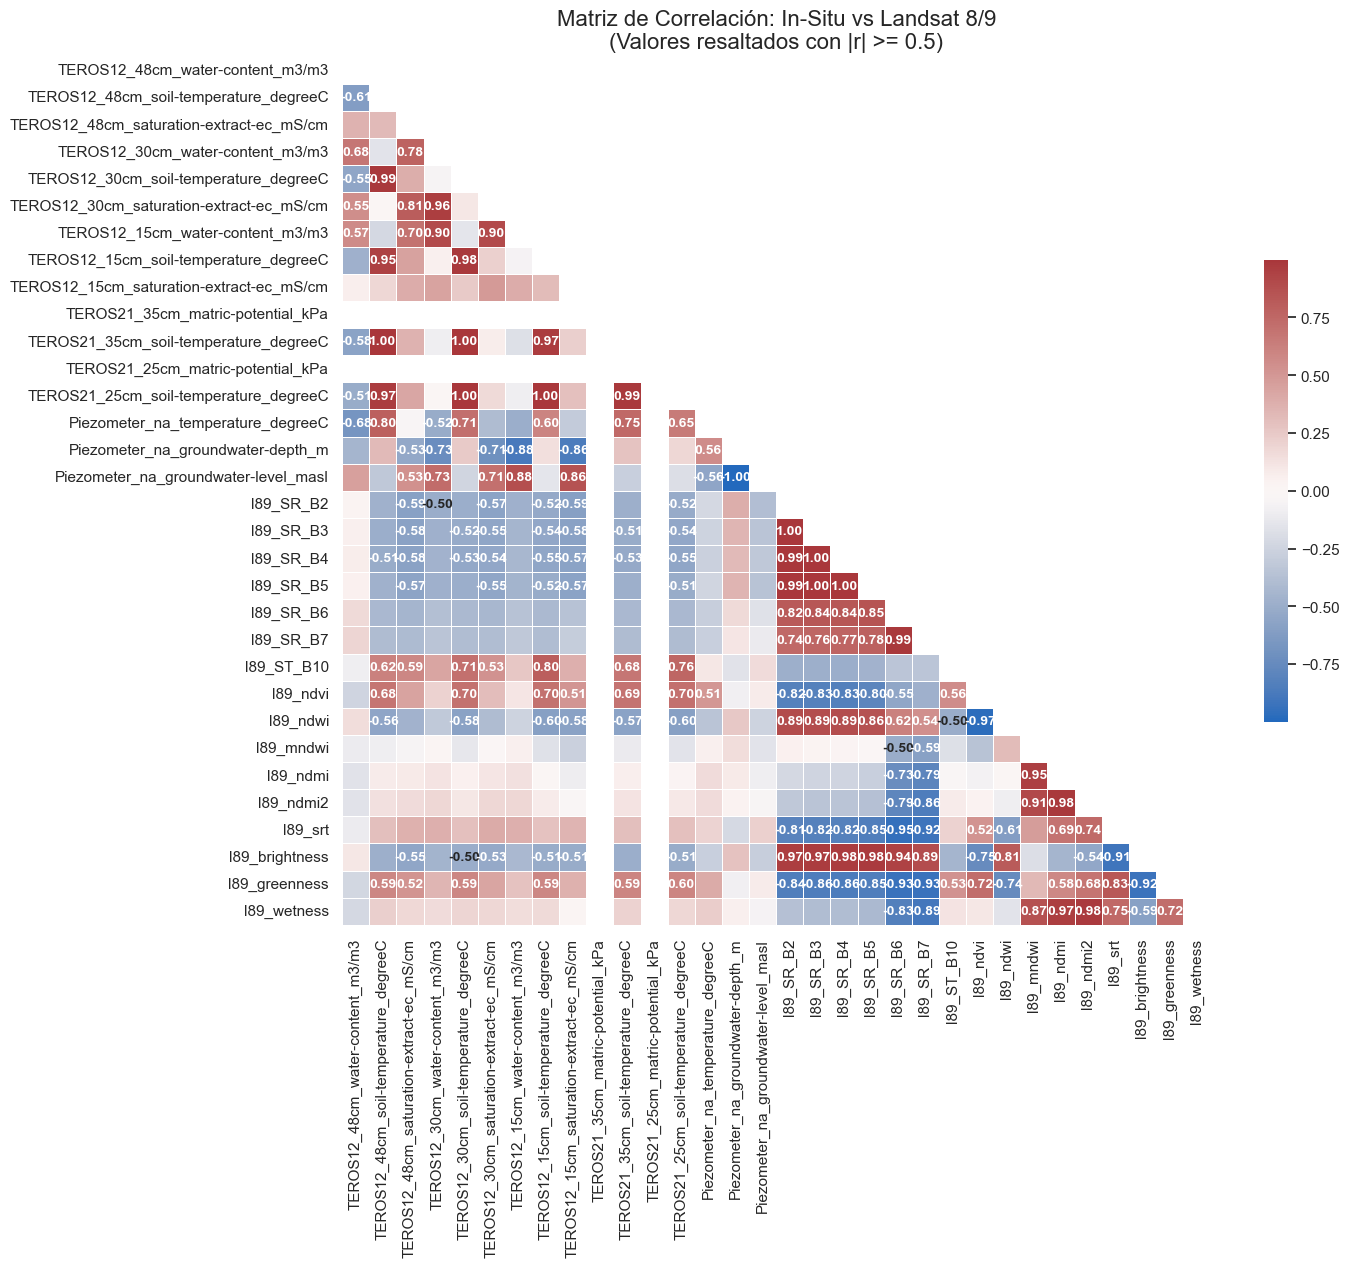

In [6]:
plot_correlation_matrix(df_landsat, "In-Situ vs Landsat 8/9")

/var/folders/jv/vkj2kxvs7vs4lb9_8bnqgr2h0000gn/T/ipykernel_1852/2305290274.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_mask = corr.applymap(lambda x: f'{x:.2f}' if abs(x) >= 0.5 else "")


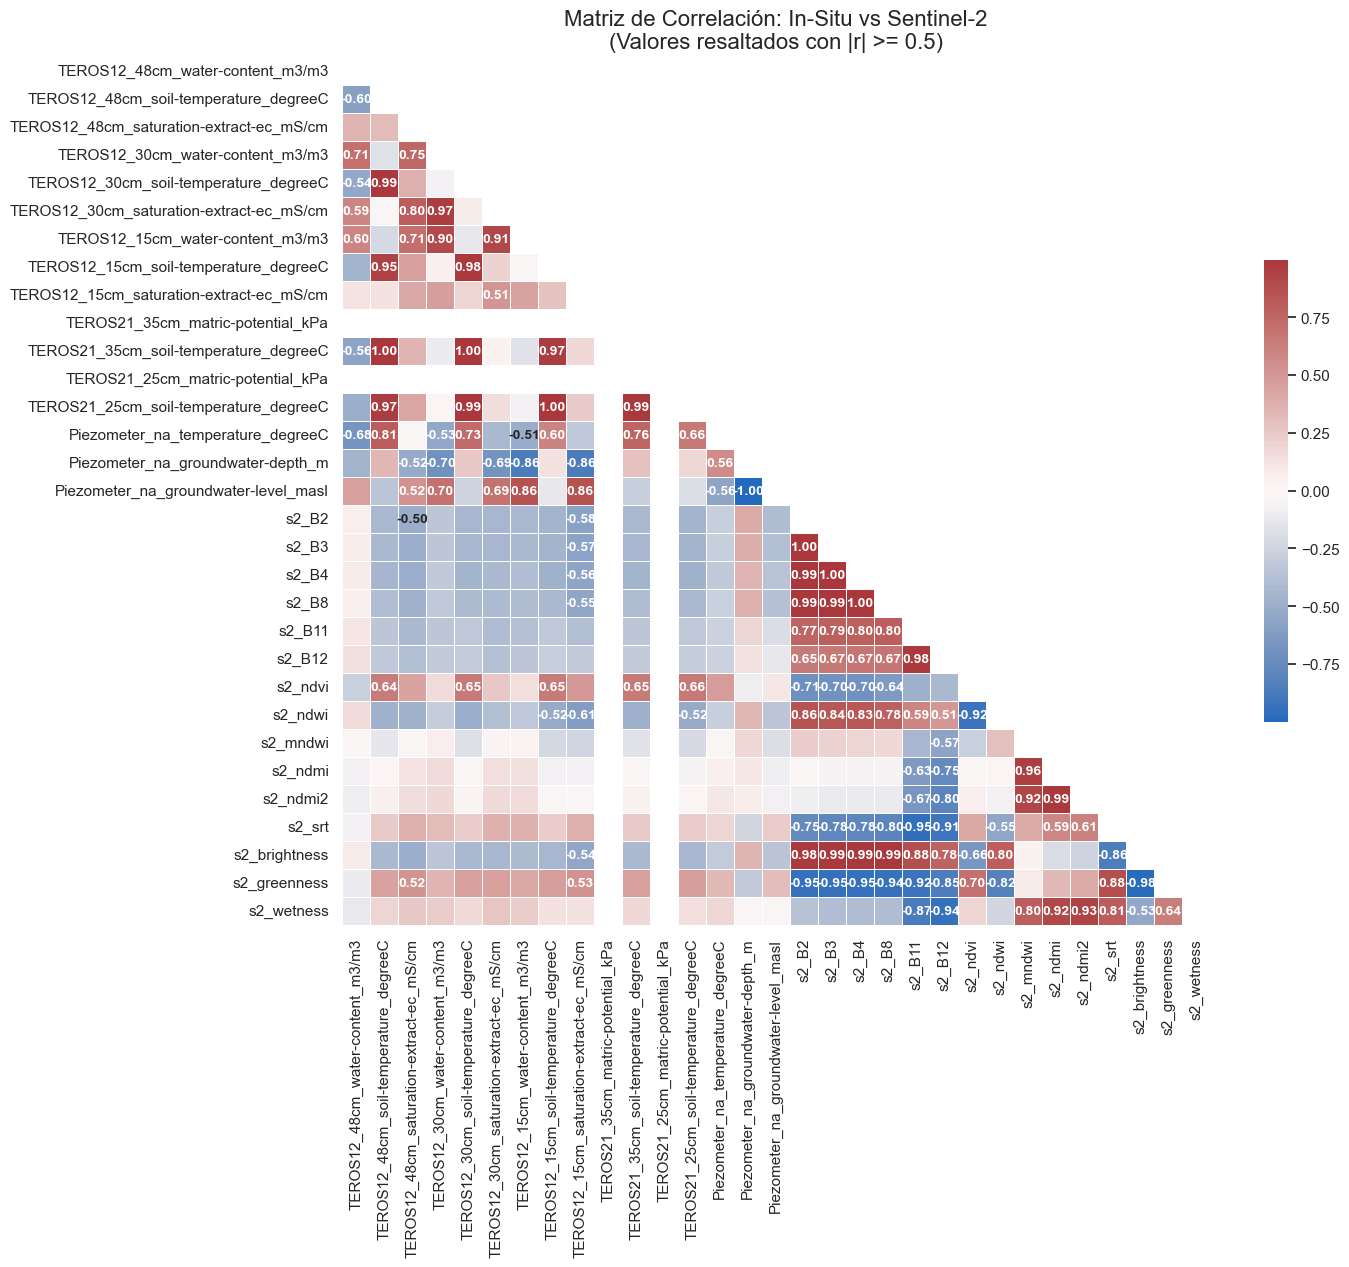

In [7]:
plot_correlation_matrix(df_sentinel2, "In-Situ vs Sentinel-2")

/var/folders/jv/vkj2kxvs7vs4lb9_8bnqgr2h0000gn/T/ipykernel_1852/2305290274.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_mask = corr.applymap(lambda x: f'{x:.2f}' if abs(x) >= 0.5 else "")


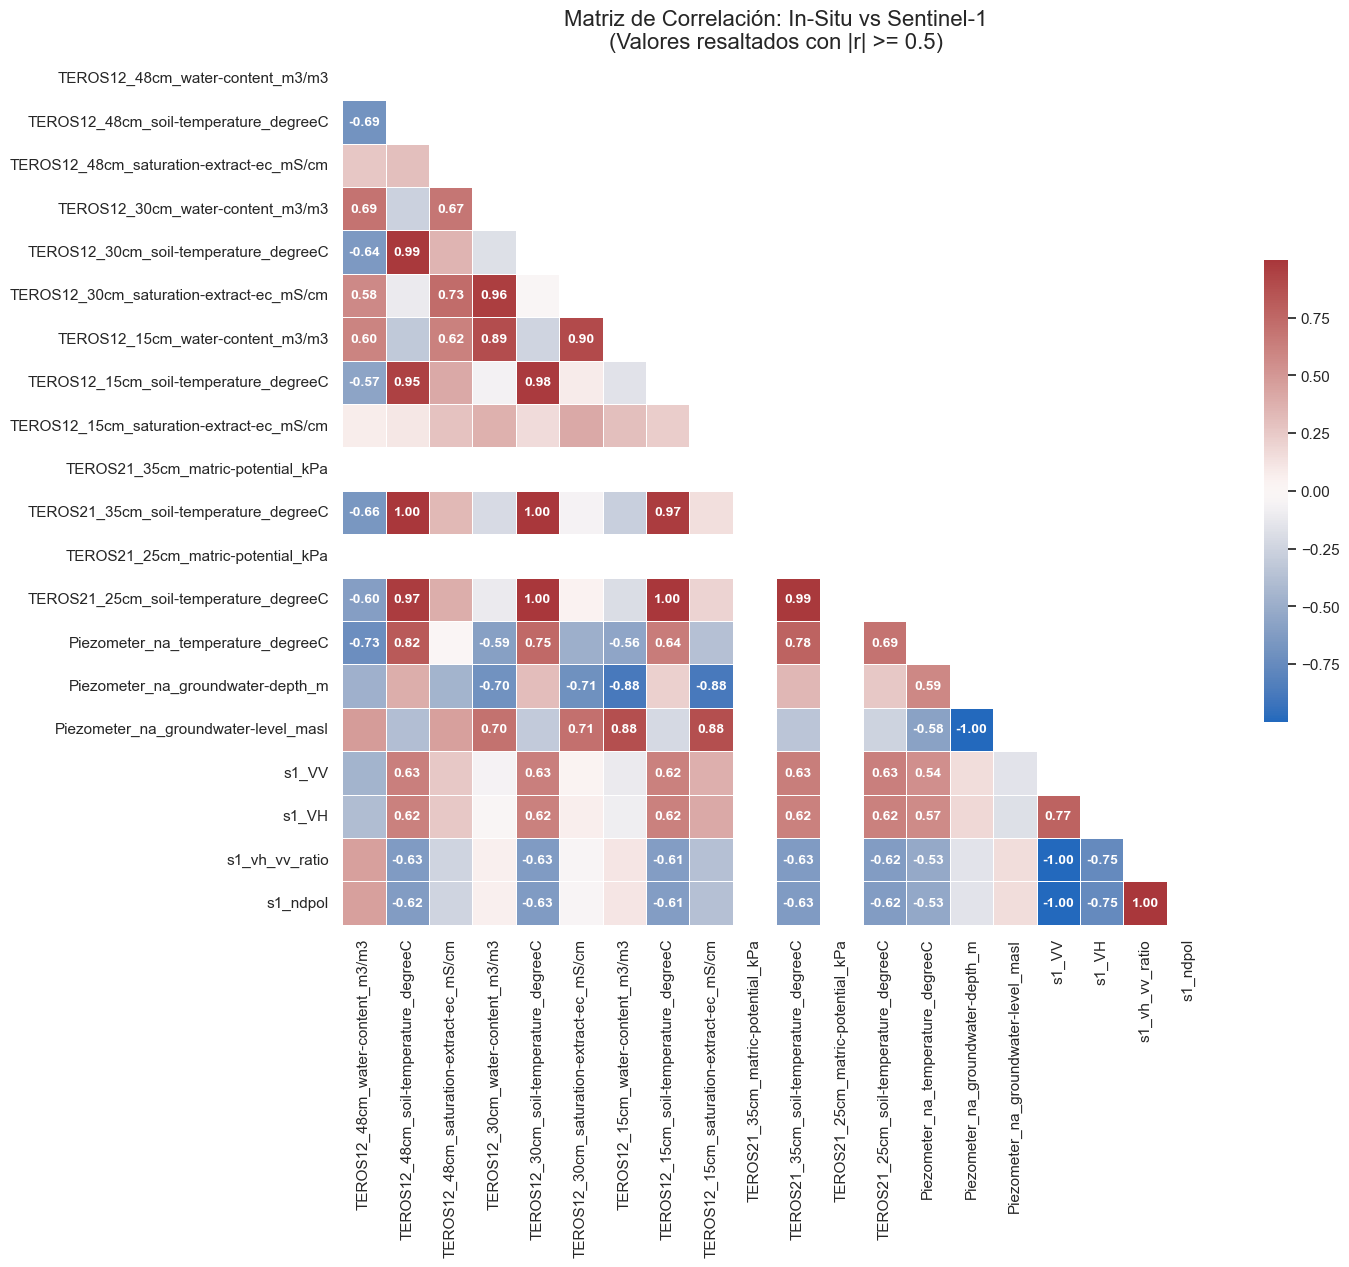

In [8]:
plot_correlation_matrix(df_sentinel1, "In-Situ vs Sentinel-1")

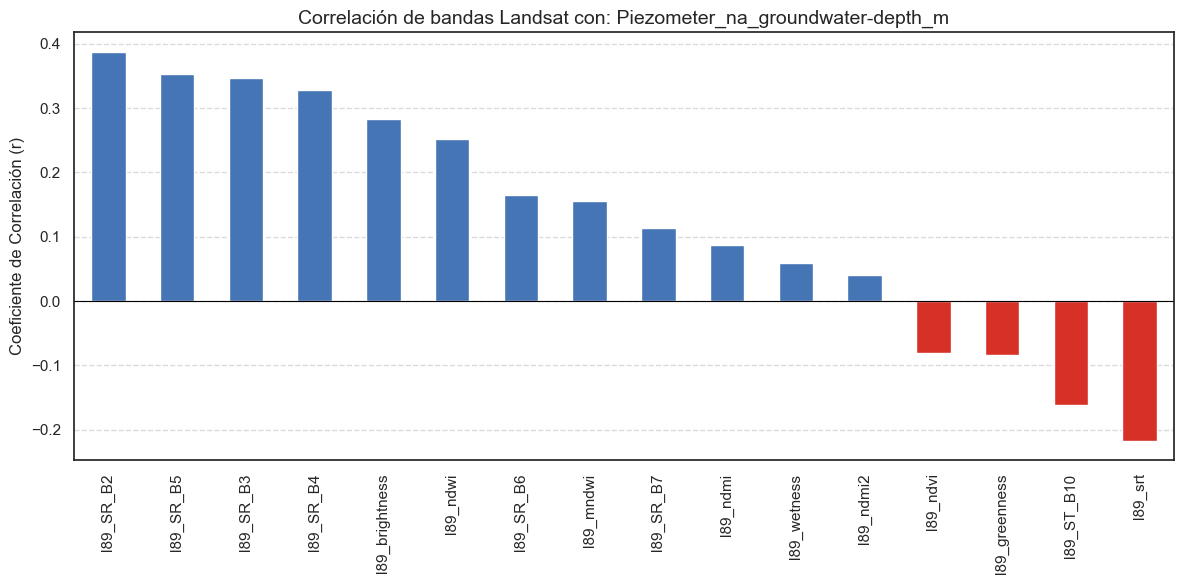

Análisis basado en 60 registros coincidentes.


In [9]:
# --- CONFIGURACIÓN ---
CURRENT_SAT = 'Landsat' 
TARGET_VAR = 'Piezometer_na_groundwater-depth_m'
# ---------------------

# Diccionario maestro de configuración
sat_config = {
    'Landsat':   {'df': df_landsat,   'cols': cols_l89},
    'Sentinel1': {'df': df_sentinel1, 'cols': cols_s1},
    'Sentinel2': {'df': df_sentinel2, 'cols': cols_s2}
}

# 1. Selección de datos
df_active = sat_config[CURRENT_SAT]['df']
cols_active = sat_config[CURRENT_SAT]['cols']

# 2. Verificación y Cálculo
if TARGET_VAR in df_active.columns:
    # Calculamos la correlación de todas las columnas contra la variable objetivo
    # Eliminamos el TARGET_VAR del resultado para que no salga la barra del 1.0
    correlations = df_active.corr(method='pearson')[TARGET_VAR].drop(TARGET_VAR, errors='ignore')
    
    # Filtramos solo las columnas que pertenecen al satélite activo
    sat_corrs = correlations.loc[correlations.index.isin(cols_active)].sort_values(ascending=False)
    
    # 3. Verificación de datos antes de graficar
    if sat_corrs.dropna().empty:
        print(f"[ADVERTENCIA] No hay suficientes datos numéricos o varianza para calcular correlaciones entre {CURRENT_SAT} y {TARGET_VAR}.")
    else:
        # Gráfico
        plt.figure(figsize=(12, 6))
        
        # Colores: Azul para positivo, Rojo para negativo
        colors = ['#d73027' if x < 0 else '#4575b4' for x in sat_corrs]
        
        # Graficar
        sat_corrs.plot(kind='bar', color=colors)
        
        plt.title(f'Correlación de bandas {CURRENT_SAT} con: {TARGET_VAR}', fontsize=14)
        plt.ylabel('Coeficiente de Correlación (r)')
        plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        print(f"Análisis basado en {len(df_active)} registros coincidentes.")
else:
    print(f"[ERROR] La variable '{TARGET_VAR}' no existe en el dataset.")

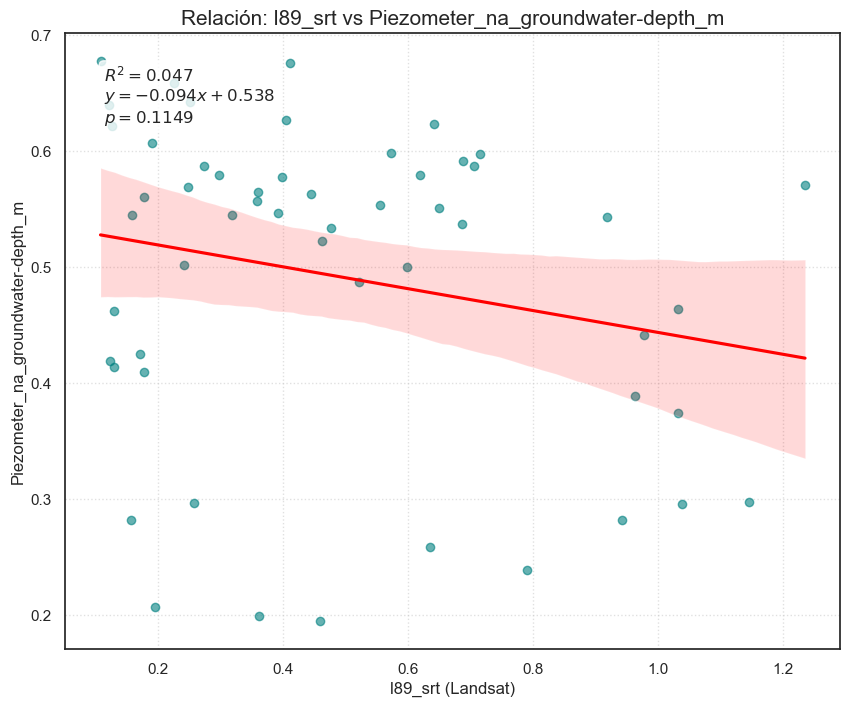

Análisis estadístico para 54 puntos coincidentes.


In [10]:
from scipy import stats

# --- CONFIGURACIÓN ---
# 1. Satélite
CURRENT_SAT = 'Landsat' 

# 2. Variable X (Satelital) - Elige la banda/índice con mejor correlación según la celda anterior
X_COL = 'l89_srt' 

# 3. Variable Y (In-situ)
Y_COL = 'Piezometer_na_groundwater-depth_m'
# ---------------------

# Selección de datos
df_active = sat_config[CURRENT_SAT]['df']

# Limpieza específica para este par de variables (elimina NaNs solo en estas 2 columnas)
# Esto es vital para que el cálculo de R2 sea correcto
data_pair = df_active[[X_COL, Y_COL]].dropna()

# Extraemos los datos limpios
x = data_pair[X_COL]
y = data_pair[Y_COL]

# Cálculo de estadísticas de regresión lineal
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2

# Gráfico
plt.figure(figsize=(10, 8))

# Scatterplot con linea de regresión
# ci=95 muestra el intervalo de confianza del 95% (sombra)
sns.regplot(x=x, y=y, color="teal", scatter_kws={'alpha':0.6}, line_kws={'color':'red'})

# Personalización
plt.title(f'Relación: {X_COL} vs {Y_COL}', fontsize=15)
plt.xlabel(f'{X_COL} ({CURRENT_SAT})', fontsize=12)
plt.ylabel(Y_COL, fontsize=12)

# Anotación del R2 y la Ecuación en el gráfico
text_str = f'$R^2 = {r_squared:.3f}$\n$y = {slope:.3f}x + {intercept:.3f}$\n$p = {p_value:.4f}$'

# Colocamos la caja de texto en la esquina superior izquierda (o cambia loc)
plt.text(0.05, 0.95, text_str, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"Análisis estadístico para {len(data_pair)} puntos coincidentes.")

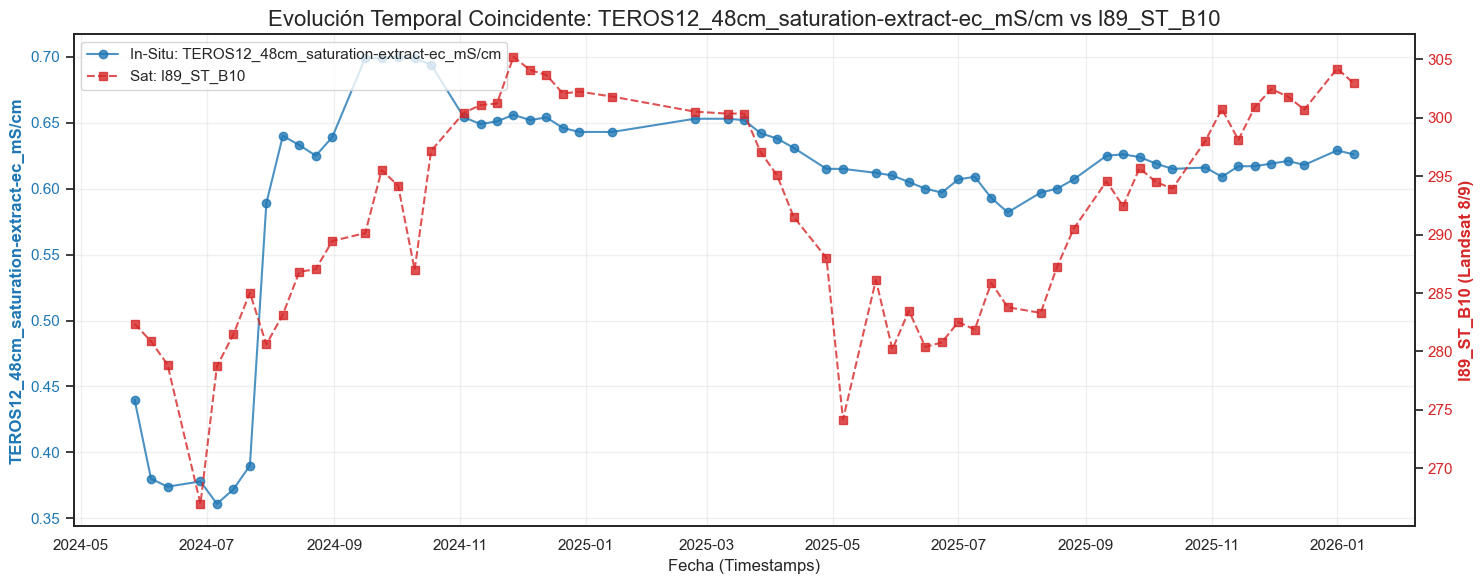

In [17]:
# --- CONFIGURACIÓN ---
# 1. Elige el satélite: 'Landsat', 'Sentinel1' o 'Sentinel2'
CURRENT_SAT = 'Landsat' 

# 2. Elige la variable satelital (debe pertenecer al satélite elegido)
SAT_VAR = 'l89_ST_B10'

# 3. Elige la variable in-situ objetivo
INSITU_VAR = 'TEROS12_48cm_saturation-extract-ec_mS/cm'
# ---------------------

# Configuración dinámica del subset
sat_config = {
    'Landsat':   {'df': df_landsat,   'label': 'Landsat 8/9'},
    'Sentinel1': {'df': df_sentinel1, 'label': 'Sentinel-1 (Radar)'},
    'Sentinel2': {'df': df_sentinel2, 'label': 'Sentinel-2'}
}

df_plot = sat_config[CURRENT_SAT]['df']
sat_label = sat_config[CURRENT_SAT]['label']

# Crear la figura
fig, ax1 = plt.subplots(figsize=(15, 6))

# --- EJE 1: Variable In-Situ ---
color_insitu = 'tab:blue'
ax1.set_xlabel('Fecha (Timestamps)')
ax1.set_ylabel(INSITU_VAR, color=color_insitu, fontsize=12, fontweight='bold')
# Graficamos con marcadores para enfatizar que son puntos coincidentes
ax1.plot(df_plot.index, df_plot[INSITU_VAR], color=color_insitu, marker='o', linestyle='-', alpha=0.8, label=f'In-Situ: {INSITU_VAR}')
ax1.tick_params(axis='y', labelcolor=color_insitu)
ax1.grid(True, alpha=0.3)

# --- EJE 2: Variable Satelital ---
# Creamos un segundo eje que comparte el mismo eje X
ax2 = ax1.twinx() 

color_sat = 'tab:red'
ax2.set_ylabel(f'{SAT_VAR} ({sat_label})', color=color_sat, fontsize=12, fontweight='bold')
ax2.plot(df_plot.index, df_plot[SAT_VAR], color=color_sat, marker='s', linestyle='--', alpha=0.8, label=f'Sat: {SAT_VAR}')
ax2.tick_params(axis='y', labelcolor=color_sat)

# Título y ajustes finales
plt.title(f'Evolución Temporal Coincidente: {INSITU_VAR} vs {SAT_VAR}', fontsize=16)
fig.tight_layout()

# Combinar leyendas de ambos ejes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()